# CSCA-5642. Final project

# Untilizing cGAN approach to colorize grayscale images


This project is essentially inspired by Pix2Pix TensorFlow tutorial, but instead of reconstructing building facades I'm applying the same technique to reconstruct colors of the grayscale images. Eventually I'm applying the trained model to colorize some historical grayscale images found in national photo archives. Images used for training are the Places365 dataset, but since I'm only trying to colorize natural scenes, I minimized presence of the human made artifacts by picking only the subset of the images from the corresponding natural categories.


I will be following thise steps:
* Subset the dataset (only retain the categories of interest)
* Create TensorFlow dataset
* Convert images to the proper format
* Basic exploratory data analysis
* Create models
* Wrap training procedure witch class structure
* Run training, make snapshots correspoding to different epochs
* Take a look at the trining metrics
* Download and colorize historical images
* Conclusion

## Dataset

Here is the dataset explanation



In [1]:
DATASET_DIR = '/kaggle/input/places365'
WORKING_DIR = '/kaggle/working'

In [2]:
!ls



first80.zip	 model-epoch-003  model-epoch-015  model-epoch-050  model.png
history.json	 model-epoch-005  model-epoch-020  model-epoch-060  state.db
model-epoch-001  model-epoch-007  model-epoch-030  model-epoch-070  train
model-epoch-002  model-epoch-010  model-epoch-040  model-epoch-080  val


Brief description of the problem and data

In [3]:
import os
import subprocess

SELECTED_CATEGORIES = [
    'badlands', 'bamboo_forest', 'butte', 'canyon', 'cliff', 'coast', 'corn_field', 'creek', 'crevasse',
    'desert-sand', 'field-cultivated', 'field-wild', 'field_road', 'forest-broadleaf', 'forest_path',
    'forest_road', 'glacier', 'hayfield', 'hot_spring', 'ice_floe', 'ice_shelf', 'iceberg', 'islet', 'lagoon',
    'lake-natural', 'marsh', 'mountain', 'mountain_path', 'mountain_snowy', 'ocean', 'pasture', 'pond',
    'rainforest', 'river', 'snowfield', 'swamp', 'tundra', 'volcano', 'waterfall']


for subset in ['train', 'val']:
    for cat in SELECTED_CATEGORIES:
        if os.path.exists(os.path.join(WORKING_DIR, subset, cat)):
            continue
        
        dataset_subset_cat = os.path.join(DATASET_DIR, subset, cat)
        working_subset = os.path.join(WORKING_DIR, subset)
        os.makedirs(working_subset, exist_ok=True)   
        subprocess.call(['rsync', '-a', dataset_subset_cat, working_subset])

In [4]:
!du -sh /kaggle/working/train
!du -sh /kaggle/working/val
#!find /kaggle/working/train -type f | wc -l
#!find /kaggle/working/val -type f | wc -l

2.8G	/kaggle/working/train
57M	/kaggle/working/val


In [5]:
## The facade training set consist of 400 images
#BUFFER_SIZE = 400
# ---------------

# The batch size of 1 produced better results for the U-Net in the original pix2pix experiment
BATCH_SIZE = 1
# Each image is 256x256 in size
IMG_WIDTH = 256
IMG_HEIGHT = 256

In [27]:
import tensorflow as tf
import numpy as np

def to_m11(image):  # from [0.0, 1.0] to [-1.0, 1.0]
    return image * 2.0 - 1.0

def to_01(image):  # from [-1.0, 1.0] to [0.0, 1.0]
    return image * 0.5 + 0.5

def to_unit8(image):  # from [0.0, 1.0] to [0, 255]
    image = np.array(image) * 255.0
    return image.astype(np.uint8)

def to_gray_and_rgb(rgb_batch):
    rgb_batch = tf.cast(rgb_batch, tf.float32) / 255.0
    gray_batch = tf.image.rgb_to_grayscale(rgb_batch)
    return to_m11(gray_batch), to_m11(rgb_batch)

def get_dataset(directory):
    rgb_dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels=None,
        batch_size=BATCH_SIZE,
        image_size=(IMG_WIDTH, IMG_HEIGHT),
        seed=5642
    )
    return rgb_dataset.map(to_gray_and_rgb)

In [34]:
train_dataset = get_dataset(os.path.join(WORKING_DIR, 'train'))
val_dataset = get_dataset(os.path.join(WORKING_DIR, 'val'))

Found 194457 files.
Found 3900 files.


# Exploratory Data Analysis (EDA)

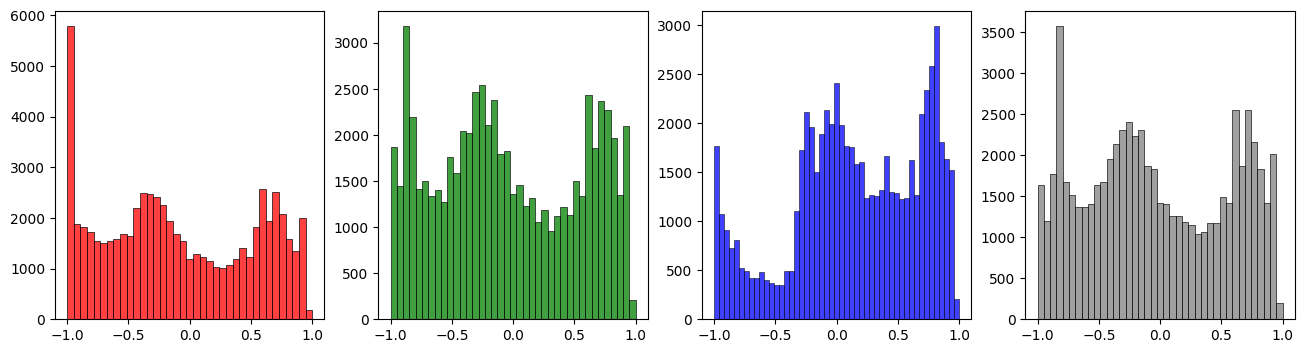

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

gray_image_batch, rgb_image_batch = next(iter(val_dataset))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
sns.histplot(tf.reshape(rgb_image_batch[:, :, :, 0], [-1]), ax=ax[0], color='red')
sns.histplot(tf.reshape(rgb_image_batch[:, :, :, 1], [-1]), ax=ax[1], color='green')
sns.histplot(tf.reshape(rgb_image_batch[:, :, :, 2], [-1]), ax=ax[2], color='blue')
sns.histplot(tf.reshape(gray_image_batch[:, :, :], [-1]), ax=ax[3], color='gray')

for ax_i in ax:
    ax_i.set_ylabel('')
    
plt.show()


### Generator

In [36]:
OUTPUT_CHANNELS = 3

In [11]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU())

    return result

In [12]:
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                        padding='same',
                                        kernel_initializer=initializer,
                                        use_bias=False))

    result.add(tf.keras.layers.BatchNormalization())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))

    result.add(tf.keras.layers.ReLU())

    return result

In [13]:
def Generator():
    inputs = tf.keras.layers.Input(shape=[256, 256, 1])  # 1 - means grayscale

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),  # (batch_size, 128, 128, 64)
        downsample(128, 4),  # (batch_size, 64, 64, 128)
        downsample(256, 4),  # (batch_size, 32, 32, 256)
        downsample(512, 4),  # (batch_size, 16, 16, 512)
        downsample(512, 4),  # (batch_size, 8, 8, 512)
        downsample(512, 4),  # (batch_size, 4, 4, 512)
        downsample(512, 4),  # (batch_size, 2, 2, 512)
        downsample(512, 4),  # (batch_size, 1, 1, 512)
    ]

    up_stack = [
        upsample(512, 4, apply_dropout=True),  # (batch_size, 2, 2, 1024)
        upsample(512, 4, apply_dropout=True),  # (batch_size, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True),  # (batch_size, 8, 8, 1024)
        upsample(512, 4),  # (batch_size, 16, 16, 1024)
        upsample(256, 4),  # (batch_size, 32, 32, 512)
        upsample(128, 4),  # (batch_size, 64, 64, 256)
        upsample(64, 4),  # (batch_size, 128, 128, 128)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 4,
                                           strides=2,
                                           padding='same',
                                           kernel_initializer=initializer,
                                           activation='tanh')  # (batch_size, 256, 256, 3)

    x = inputs

    # Downsampling through the model
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

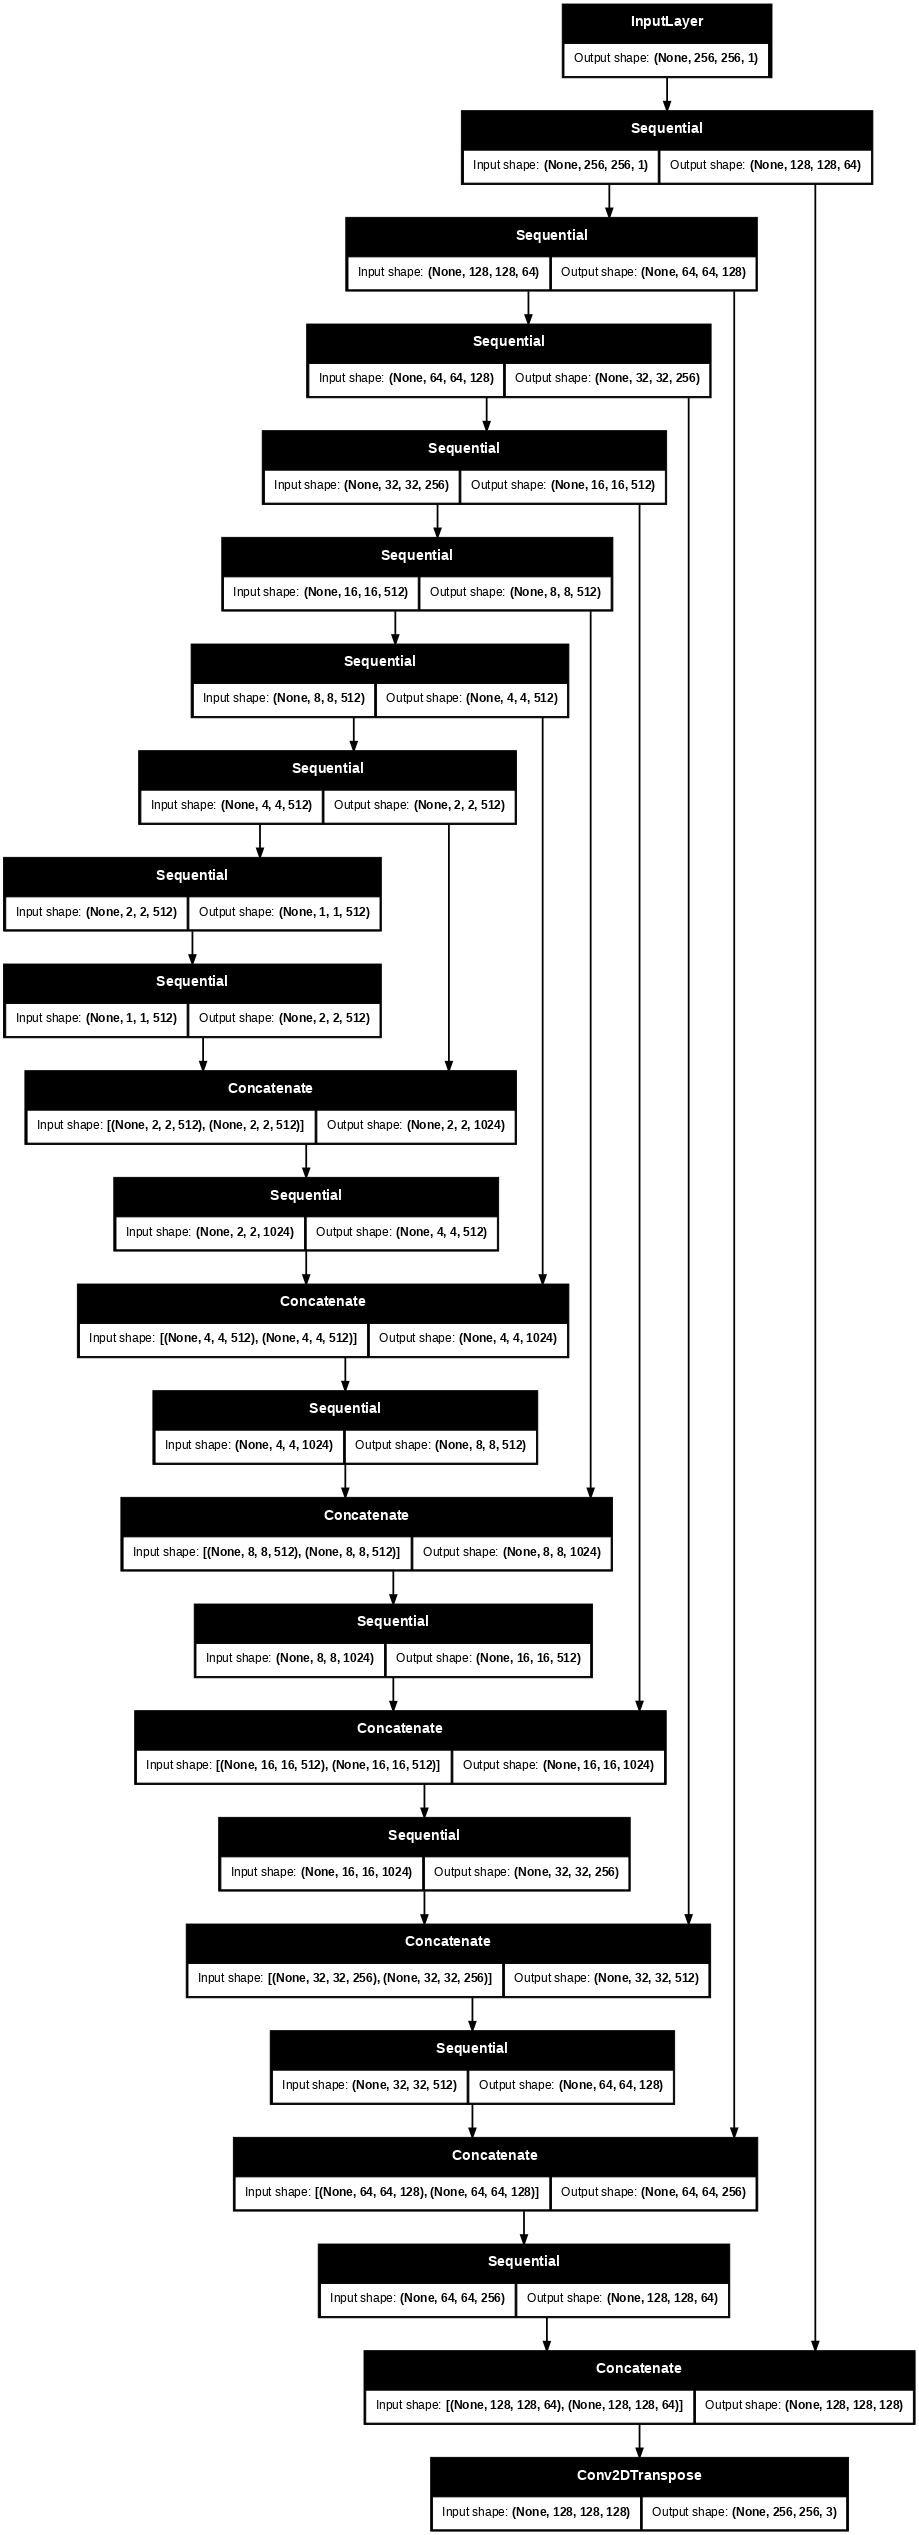

In [14]:
#generator = Generator()
#tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

### Generator loss

In [15]:
LAMBDA = 100

In [16]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [17]:
def generator_loss(disc_generated_output, gen_output, target, l1_loss_amplifier):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

    # Mean absolute error
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

    total_gen_loss = gan_loss + (l1_loss_amplifier * l1_loss)

    return total_gen_loss, gan_loss, l1_loss

### Discriminator

In [18]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = tf.keras.layers.Input(shape=[256, 256, 1], name='input_image')  # 1 - means grayscale
    tar = tf.keras.layers.Input(shape=[256, 256, 3], name='target_image')

    x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

    down1 = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
    down2 = downsample(128, 4)(down1)  # (batch_size, 64, 64, 128)
    down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (batch_size, 34, 34, 256)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                  kernel_initializer=initializer,
                                  use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

    batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

    last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                  kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

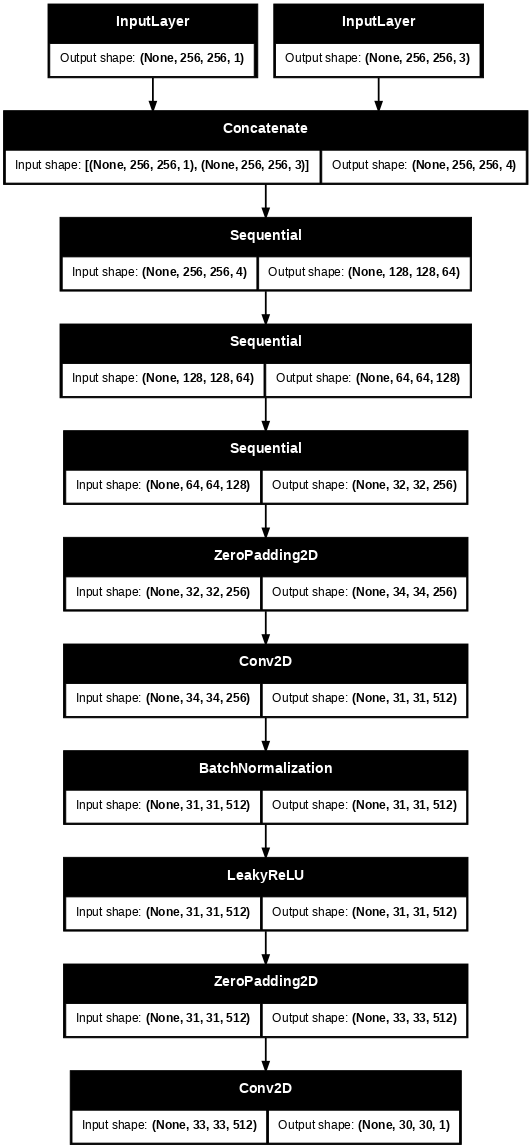

In [19]:
#discriminator = Discriminator()
#tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64)

### Discriminator loss

In [20]:
def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

### Optimizers

In [21]:
#generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
#discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

### Model

In [60]:
class ConditionalGan(tf.keras.Model):
    def __init__(self, generator, discriminator, l1_loss_amplifier):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.l1_loss_amplifier = l1_loss_amplifier

        self.gen_total_loss_tracker = tf.keras.metrics.Mean(name="gen_total_loss")
        self.gen_gan_loss_tracker = tf.keras.metrics.Mean(name="gen_gan_loss")
        self.gen_l1_loss_tracker = tf.keras.metrics.Mean(name="gen_l1_loss")
        self.disc_loss_tracker = tf.keras.metrics.Mean(name="disc_loss")

    def compile(self, generator_optimizer, discriminator_optimizer):
        super(ConditionalGan, self).compile()
        self.generator_optimizer = generator_optimizer
        self.discriminator_optimizer = discriminator_optimizer

    @property
    def metrics(self):        
        return [
            self.gen_total_loss_tracker,
            self.gen_gan_loss_tracker,
            self.gen_l1_loss_tracker,
            self.disc_loss_tracker
        ]
    
    def generator_loss(self, disc_generated_output, gen_output, target):
        gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

        # Mean absolute error
        l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

        total_gen_loss = gan_loss + (self.l1_loss_amplifier * l1_loss)
        return total_gen_loss, gan_loss, l1_loss
    
    def discriminator_loss(self, disc_real_output, disc_generated_output):
        real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

        generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

        total_disc_loss = real_loss + generated_loss
        return total_disc_loss
    
    @tf.function
    def train_step(self, data):
        input_image, target_image = data

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            gen_output = self.generator(input_image, training=True)
            disc_real_output = self.discriminator([input_image, target_image], training=True)
            disc_generated_output = self.discriminator([input_image, gen_output], training=True)
            gen_total_loss, gen_gan_loss, gen_l1_loss = self.generator_loss(disc_generated_output, gen_output, target_image)
            disc_loss = self.discriminator_loss(disc_real_output, disc_generated_output)

        self.gen_total_loss_tracker.update_state(gen_total_loss)
        self.gen_gan_loss_tracker.update_state(gen_gan_loss)
        self.gen_l1_loss_tracker.update_state(gen_l1_loss)
        self.disc_loss_tracker.update_state(disc_loss)

        generator_gradients = gen_tape.gradient(gen_total_loss, self.generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.generator_optimizer.apply_gradients(zip(generator_gradients, self.generator.trainable_variables))
        self.discriminator_optimizer.apply_gradients(zip(discriminator_gradients, self.discriminator.trainable_variables))

        return {m.name: m.result() for m in self.metrics}
    
    @tf.function
    def test_step(self, data):
        input_image, target_image = data

        gen_output = self.generator(input_image, training=True)
        disc_real_output = self.discriminator([input_image, target_image], training=True)
        disc_generated_output = self.discriminator([input_image, gen_output], training=True)
        gen_total_loss, gen_gan_loss, gen_l1_loss = self.generator_loss(disc_generated_output, gen_output, target_image)
        disc_loss = self.discriminator_loss(disc_real_output, disc_generated_output)

        self.gen_total_loss_tracker.update_state(gen_total_loss)
        self.gen_gan_loss_tracker.update_state(gen_gan_loss)
        self.gen_l1_loss_tracker.update_state(gen_l1_loss)
        self.disc_loss_tracker.update_state(disc_loss)

        return {m.name: m.result() for m in self.metrics}

In [50]:
#model = ConditionalGan(generator, discriminator, 100)
#model.compile(generator_optimizer, discriminator_optimizer)

### Training

In [57]:
import json

def save_metrics(data, file_path):
    with open(file_path, 'w') as f:
        json.dump(data, f, indent=4)

def load_metrics(file_path):
    with open(file_path) as f:
        return json.load(f)


class ModelEpochEndCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, save_epochs, save_dir):
        super().__init__()
        self.save_epochs = save_epochs
        self.save_dir = save_dir
        pass
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in self.save_epochs:
            epoch_dir = os.path.join(self.save_dir, f'epoch-{(epoch + 1):03}')
            os.makedirs(epoch_dir, exist_ok=True)
            generator.save_weights(os.path.join(epoch_dir, 'generator.weights.h5'))

In [58]:
STEPS_PER_EPOCH = 50
VALIDATION_STEPS = 50

In [61]:
save_generator_cb1 = ModelEpochEndCheckpoint(
    save_epochs=[1,2,3,5,7,10,15,20,25,30,40,50,60,70,80,90,100,110,120],
    save_dir=os.path.join(WORKING_DIR, 'lambda-100'))

generator1 = Generator()
discriminator1 = Discriminator()
generator_optimizer1 = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer1 = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

model1 = ConditionalGan(generator1, discriminator1, l1_loss_amplifier=100)  # LABMDA=100
model1.compile(generator_optimizer1, discriminator_optimizer1)

history1 = model1.fit(train_dataset.repeat(),
                      epochs=2,
                      steps_per_epoch=STEPS_PER_EPOCH,
                      validation_data=val_dataset.repeat(),
                      validation_steps=VALIDATION_STEPS,
                      callbacks=[save_generator_cb1])


save_metrics(history1.history, os.path.join(WORKING_DIR, 'history-100.json'))

Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - disc_loss: 1.8301 - gen_gan_loss: 0.9535 - gen_l1_loss: 0.3377 - gen_total_loss: 34.7255 - val_disc_loss: 1.3930 - val_gen_gan_loss: 0.7125 - val_gen_l1_loss: 0.2211 - val_gen_total_loss: 22.8182
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - disc_loss: 1.3819 - gen_gan_loss: 0.7468 - gen_l1_loss: 0.2290 - gen_total_loss: 23.6491 - val_disc_loss: 1.3431 - val_gen_gan_loss: 0.7545 - val_gen_l1_loss: 0.1900 - val_gen_total_loss: 19.7529


In [ ]:
import json

# Recreate all the objects, start from scratch

save_generator_cb = ModelEpochEndCheckpoint(
    save_epochs=[1,2,3,5,7,10,15,20,25,30,40,50,60,70,80,90,100,110,120],
    save_dir=os.path.join(WORKING_DIR, 'checkpoints-lambda-200'))

generator = Generator()
discriminator = Discriminator()
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

model = ConditionalGan(generator, discriminator, l1_loss_amplifier=200)  # LABMDA=200
model.compile(generator_optimizer, discriminator_optimizer)

history2 = model1.fit(train_dataset.repeat(),
                      epochs=120,
                      steps_per_epoch=STEPS_PER_EPOCH,
                      validation_data=val_dataset.repeat(),
                      validation_steps=VALIDATION_STEPS,
                      callbacks=[save_generator_cb1])


with open(os.path.join(WORKING_DIR, 'history-200.json'), 'w') as jf:
    json.dump(history1.history, jf, indent=4)

In [40]:
#!rm -rf *.zip
#!rm -rf *.json
#!rm -rf model-epoch*

!ls -l

total 9060
-rw-r--r--  1 root root   65015 Dec  5 22:46 model.png
-rw-r--r--  1 root root 9200005 Dec  5 22:25 state.db
drwxr-xr-x 41 root root    4096 Dec  5 22:27 train
drwxr-xr-x 41 root root    4096 Dec  5 22:27 val


In [27]:
!zip -r first50.zip model-epoch* history*

  adding: model-epoch-001/ (stored 0%)
  adding: model-epoch-001/generator.weights.h5 (deflated 7%)
  adding: model-epoch-002/ (stored 0%)
  adding: model-epoch-002/generator.weights.h5 (deflated 7%)
  adding: model-epoch-003/ (stored 0%)
  adding: model-epoch-003/generator.weights.h5 (deflated 7%)
  adding: model-epoch-005/ (stored 0%)
  adding: model-epoch-005/generator.weights.h5 (deflated 7%)
  adding: model-epoch-007/ (stored 0%)
  adding: model-epoch-007/generator.weights.h5 (deflated 7%)
  adding: model-epoch-010/ (stored 0%)
  adding: model-epoch-010/generator.weights.h5 (deflated 7%)
  adding: model-epoch-015/ (stored 0%)
  adding: model-epoch-015/generator.weights.h5 (deflated 7%)
  adding: model-epoch-020/ (stored 0%)
  adding: model-epoch-020/generator.weights.h5 (deflated 7%)
  adding: model-epoch-030/ (stored 0%)
  adding: model-epoch-030/generator.weights.h5 (deflated 7%)
  adding: model-epoch-040/ (stored 0%)
  adding: model-epoch-040/generator.weights.h5 (deflated 7%)


In [30]:
#mv first50.zip first80.zip

!ls -l

total 2761704
-rw-r--r--  1 root root 2827822322 Dec  5 05:17 first80.zip
-rw-r--r--  1 root root      18456 Dec  5 05:14 history.json
drwxr-xr-x  2 root root       4096 Dec  5 00:23 model-epoch-001
drwxr-xr-x  2 root root       4096 Dec  5 00:27 model-epoch-002
drwxr-xr-x  2 root root       4096 Dec  5 00:31 model-epoch-003
drwxr-xr-x  2 root root       4096 Dec  5 00:38 model-epoch-005
drwxr-xr-x  2 root root       4096 Dec  5 00:45 model-epoch-007
drwxr-xr-x  2 root root       4096 Dec  5 00:56 model-epoch-010
drwxr-xr-x  2 root root       4096 Dec  5 01:15 model-epoch-015
drwxr-xr-x  2 root root       4096 Dec  5 01:33 model-epoch-020
drwxr-xr-x  2 root root       4096 Dec  5 02:10 model-epoch-030
drwxr-xr-x  2 root root       4096 Dec  5 02:47 model-epoch-040
drwxr-xr-x  2 root root       4096 Dec  5 03:24 model-epoch-050
drwxr-xr-x  2 root root       4096 Dec  5 04:01 model-epoch-060
drwxr-xr-x  2 root root       4096 Dec  5 04:38 model-epoch-070
drwxr-xr-x  2 root root       409

In [32]:
class ModelEpochEndCheckpoint(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in [1,2,3,5,7,10,15,20,30,40,50]:
            epoch_dir = os.path.join(WORKING_DIR, f'model-epoch-{(epoch + 1):03}')
            os.makedirs(epoch_dir, exist_ok=True)
            generator.save_weights(os.path.join(epoch_dir, 'generator.weights.h5'))

save_generator_cb = ModelEpochEndCheckpoint()

In [33]:
import json

history2 = model.fit(train_dataset.repeat(),
                     epochs=50,
                     initial_epoch=40,
                     steps_per_epoch=STEPS_PER_EPOCH,
                     validation_data=val_dataset.repeat(),
                     validation_steps=VALIDATION_STEPS,
                     callbacks=[save_generator_cb])


with open(os.path.join(WORKING_DIR, 'history2.json'), 'w') as jf:
    json.dump(history.history, jf, indent=4)

Epoch 41/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 219s 44ms/step - disc_loss: 0.0207 - gen_gan_loss: 8.7753 - gen_l1_loss: 0.0958 - gen_total_loss: 18.3562 - val_disc_loss: 5.1753e-05 - val_gen_gan_loss: 11.3466 - val_gen_l1_loss: 0.0978 - val_gen_total_loss: 21.1223
Epoch 42/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 218s 44ms/step - disc_loss: 4.3041e-05 - gen_gan_loss: 11.1759 - gen_l1_loss: 0.0981 - gen_total_loss: 20.9822 - val_disc_loss: 4.9526e-06 - val_gen_gan_loss: 13.3381 - val_gen_l1_loss: 0.0989 - val_gen_total_loss: 23.2304
Epoch 43/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 219s 44ms/step - disc_loss: 2.7257e-06 - gen_gan_loss: 14.0443 - gen_l1_loss: 0.0977 - gen_total_loss: 23.8133 - val_disc_loss: 4.4299e-07 - val_gen_gan_loss: 15.6620 - val_gen_l1_loss: 0.1001 - val_gen_total_loss: 25.6702
Epoch 44/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 220s 44ms/step - disc_loss: 1.3297e-04 - gen_gan_loss: 16.2930 - gen_l1_loss: 0.0995 - gen_total_loss: 26.2445 - val_disc_loss: 1.0608 - val_gen_gan_loss: 3.4134 - 

In [35]:
!zip -r first50.zip model-epoch* history*

  adding: model-epoch-001/ (stored 0%)
  adding: model-epoch-001/generator.weights.h5 (deflated 7%)
  adding: model-epoch-002/ (stored 0%)
  adding: model-epoch-002/generator.weights.h5 (deflated 7%)
  adding: model-epoch-003/ (stored 0%)
  adding: model-epoch-003/generator.weights.h5 (deflated 7%)
  adding: model-epoch-005/ (stored 0%)
  adding: model-epoch-005/generator.weights.h5 (deflated 7%)
  adding: model-epoch-007/ (stored 0%)
  adding: model-epoch-007/generator.weights.h5 (deflated 7%)
  adding: model-epoch-010/ (stored 0%)
  adding: model-epoch-010/generator.weights.h5 (deflated 7%)
  adding: model-epoch-015/ (stored 0%)
  adding: model-epoch-015/generator.weights.h5 (deflated 7%)
  adding: model-epoch-020/ (stored 0%)
  adding: model-epoch-020/generator.weights.h5 (deflated 7%)
  adding: model-epoch-030/ (stored 0%)
  adding: model-epoch-030/generator.weights.h5 (deflated 7%)
  adding: model-epoch-040/ (stored 0%)
  adding: model-epoch-040/generator.weights.h5 (deflated 7%)


# -----------------

In [7]:
import tensorflow as tf
import os
AUTOTUNE = tf.data.AUTOTUNE

selected_categories = [
    'badlands', 'bamboo_forest', 'butte', 'canyon', 'cliff', 'coast', 'corn_field', 'creek', 'crevasse', 'desert-sand', 'field-cultivated',
    'field-wild', 'field_road', 'forest-broadleaf', 'forest_path', 'forest_road', 'glacier', 'hayfield', 'hot_spring', 'ice_floe',
    'ice_shelf', 'iceberg', 'islet', 'lagoon', 'lake-natural', 'marsh', 'mountain', 'mountain_path', 'mountain_snowy', 'ocean', 'pasture',
    'pond', 'rainforest', 'river', 'snowfield', 'swamp', 'tundra', 'volcano', 'waterfall']

def load_images(path):
    rgb = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    gry = tf.image.rgb_to_grayscale(rgb)
    return rgb, gry

def get_filepath_ds(categories, subset):
    datasets = []
    for cat in categories:
        cat_jpegs = os.path.join(DATASET_DIR, subset, cat, '*.jpg')
        ds = tf.data.Dataset.list_files(cat_jpegs, shuffle=False)
        datasets.append(ds)

    filepath_ds = datasets[0]
    for ds in datasets[1:]:
        filepath_ds = filepath_ds.concatenate(ds)
    return filepath_ds

def get_dataset(categories, subset):
    filepath_ds = get_filepath_ds(categories, subset)
    dataset = filepath_ds.map(load_images, num_parallel_calls=AUTOTUNE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset


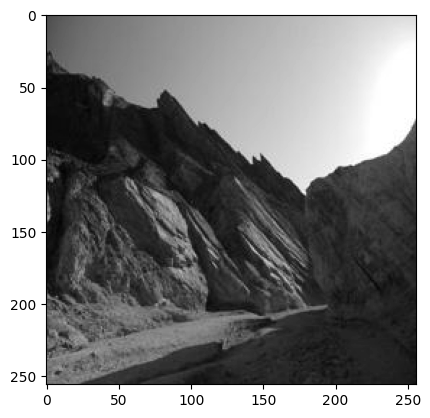

In [9]:
from matplotlib import pyplot as plt
train_dataset = get_dataset(selected_categories, 'train')
val_dataset = get_dataset(selected_categories, 'val')

n = next(iter(val_dataset ))

plt.imshow(n[1], cmap='gray')
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
import random
from PIL import Image

#categories = os.listdir('/kaggle/input/places365/train')
#categories = sorted(categories)
#categories = categories[350:400]
#print(categories)


selected_categories_set = {
    'iceberg', 'rainforest', 'hayfield', 'pasture', 'pond', 'field-wild', 'snowfield', 'ice_shelf', 'forest_path', 'bamboo_forest',
    'canyon', 'desert-sand', 'glacier', 'crevasse', 'lake-natural', 'mountain', 'creek', 'waterfall', 'field-cultivated', 'ice_floe',
    'tundra', 'lagoon', 'river', 'hot_spring', 'coast', 'ocean', 'field_road', 'mountain_path', 'forest-broadleaf', 'corn_field',
    'forest_road', 'badlands', 'islet', 'swamp', 'volcano', 'marsh', 'mountain_snowy', 'cliff', 'butte'
}


selected_categories = sorted(list(selected_categories_set))

#n = len(categories)
m = 10


def get_n_good(cat_dir, m):
    cat_jpegs = list(os.listdir(cat_dir))
    random.shuffle(cat_jpegs)


    good = list()
    for jpeg in cat_jpegs:
        if len(good) == m:
            break

        file_name = os.path.join(cat_dir, jpeg)
        img = Image.open(file_name)
            
        if img.size == (256, 256):
            good.append(img)
    
    return good


for i, cat in enumerate(selected_categories):
    cat_dir = os.path.join('/kaggle/input/places365/train', cat)
    good_jpegs = get_n_good(cat_dir, m)

    fig, ax = plt.subplots(nrows=1, ncols=m, figsize=(4*m, 4))
    ax[0].set_ylabel(cat)
    for j, img in enumerate(good_jpegs):        
        ax[j].imshow(img)
        ax[j].set_yticks([])
        ax[j].set_xticks([])

    plt.show()




#for d in os.listdir('/kaggle/input/places365/train'):
#    p = os.path.join('/kaggle/input/places365/train', d)

In [23]:
import requests
import io
import numpy as np
from PIL import Image

def make_square(img):
    w, h = img.size

    # Side length of the square (smallest dimension)
    side = min(w, h)

    # Coordinates for centered square
    left   = (w - side) // 2
    top    = (h - side) // 2
    right  = left + side
    bottom = top + side

    square = img.crop((left, top, right, bottom))
    return square.resize((256,256))

def chop_margins(img):
    w,h = img.size
    return img.crop([50,50,w-50,h-50])


def download_image(url):
    response = requests.get(url)
    return Image.open(io.BytesIO(response.content))

In [24]:
img = download_image('https://s3.us-east-1.amazonaws.com/NARAprodstorage/lz/stillpix/079-aah/079-AAH-03_14-1387M.TIF')
img = chop_margins(img)
img = make_square(img)
img = np.asarray(img) / 255.0
img = to_m11(img)


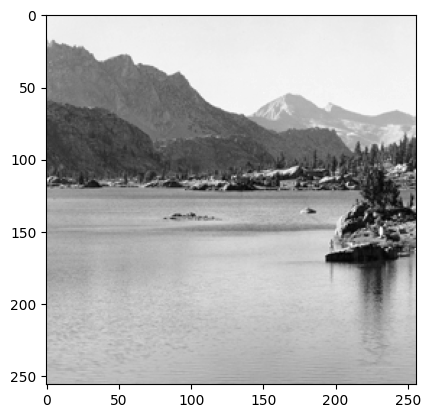

In [25]:
plt.imshow(img * 0.5 + 0.5, cmap='gray')
plt.show()

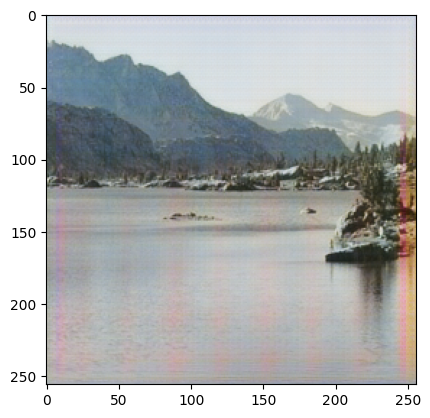

In [32]:
input_tensor = tf.stack([img])
output_tensor = generator(input_tensor, training=False)
pred = output_tensor[0]
plt.imshow(pred * 0.5 + 0.5)
plt.show()

In [31]:
w = os.path.join(WORKING_DIR, 'model-epoch-002', 'generator.weights.h5')
generator.load_weights(w)

In [33]:
194457/5000

38.8914

In [38]:
!rm dirs.txt

dELETE ME!

# Summary

### References